In [11]:
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions (1).csv


In [12]:
import pandas as pd

df = pd.read_csv('q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [13]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Extracted time-based features to capture seasonal patterns.

In [14]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

Random split avoided because time order matters in forecasting.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ])

In [16]:
X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

for name, model in {'Linear Regression': lr_pipeline, 'Random Forest': rf_pipeline}.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)


Linear Regression
RMSE: 39.63930566724027
MAE: 29.301340891734775

Random Forest
RMSE: 42.72652188917671
MAE: 34.17562777777778


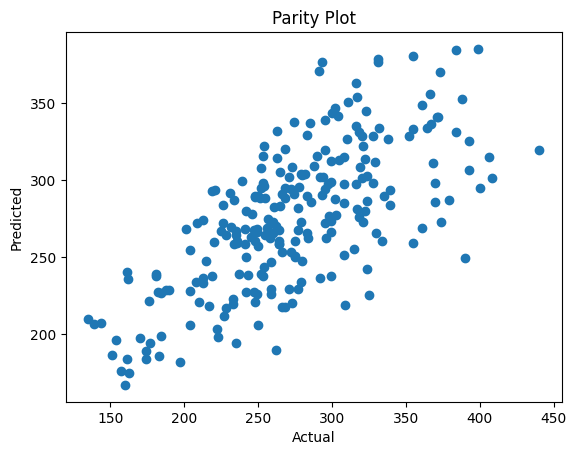

In [19]:
import matplotlib.pyplot as plt

y_pred = rf_pipeline.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Parity Plot')
plt.show()

In [20]:
model = rf_pipeline.named_steps['model']
importances = model.feature_importances_

print(importances)

[0.02864734 0.01883388 0.02029    0.03625963 0.04071399 0.1443029
 0.06549743 0.18783171 0.10616385 0.04403611 0.10611121 0.18493502
 0.01637693]


Top features influencing sales include...